# Week 2 Homework
## A daļa – Klasifikācija
## B daļa – Regresija
## C daļa – Modeļu salīdzinājums

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../week1/shoppers_clean.csv')

print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()

Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.293024
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.325076
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.998552


# A daļa – Klasifikācija

Šajā daļā tiek prognozēts, vai lietotājs veiks pirkumu (`Revenue`).

In [14]:
# Klasifikācijas target
y_cls = df['Revenue']

# Features
X_cls = df.drop('Revenue', axis=1)

print(f"Features skaits: {X_cls.shape[1]}")
print("Target: Revenue")

Features skaits: 27
Target: Revenue


In [15]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train_cls.shape[0]} rindas")
print(f"Testa kopa: {X_test_cls.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
lr_model_cls = LogisticRegression(max_iter=1000)

dt_model.fit(X_train_cls, y_train_cls)
rf_model.fit(X_train_cls, y_train_cls)
lr_model_cls.fit(X_train_cls, y_train_cls)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
from sklearn.metrics import f1_score

# Prognozes
y_pred_dt = dt_model.predict(X_test_cls)
y_pred_rf = rf_model.predict(X_test_cls)
y_pred_lr = lr_model_cls.predict(X_test_cls)

# F1 score
f1_dt = f1_score(y_test_cls, y_pred_dt)
f1_rf = f1_score(y_test_cls, y_pred_rf)
f1_lr = f1_score(y_test_cls, y_pred_lr)

print("=== F1 score ===")
print(f"Decision Tree: {f1_dt:.4f}")
print(f"Random Forest: {f1_rf:.4f}")
print(f"Logistic Regression: {f1_lr:.4f}")

=== F1 score ===
Decision Tree: 0.5729
Random Forest: 0.6143
Logistic Regression: 0.4809


### F1 score interpretācija

Dati ir nelīdzsvaroti (~15% pirkumu), tāpēc F1 score ir svarīgākā metrika.

- Random Forest sasniedz labāko rezultātu (~0.61)
- Decision Tree ir nedaudz vājāks (~0.57)
- Logistic Regression ir visvājākais (~0.48)

Tas nozīmē, ka Random Forest vislabāk identificē lietotājus, kas veic pirkumu.
Tas ir īpaši svarīgi biznesa kontekstā, jo modelis palīdz identificēt potenciālos klientus, kas varētu veikt pirkumu, un uz tiem var fokusēt mārketinga aktivitātes.

In [18]:
from sklearn.metrics import confusion_matrix

print("=== Decision Tree ===")
print(confusion_matrix(y_test_cls, y_pred_dt))

print("\n=== Random Forest ===")
print(confusion_matrix(y_test_cls, y_pred_rf))

print("\n=== Logistic Regression ===")
print(confusion_matrix(y_test_cls, y_pred_lr))

=== Decision Tree ===
[[1893  162]
 [ 181  230]]

=== Random Forest ===
[[1981   74]
 [ 196  215]]

=== Logistic Regression ===
[[2008   47]
 [ 266  145]]


### Confusion Matrix interpretācija

Confusion matrix parāda, cik labi modelis klasificē rezultātus:

- True Negative – pareizi prognozēts, ka lietotājs nepirks  
- True Positive – pareizi prognozēts pirkums  
- False Positive – prognozē pirkumu, bet tā nav  
- False Negative – modelis palaida garām pirkumu  

Salīdzinot modeļus, redzams, ka:

- Random Forest modelis rada mazāk kļūdu un nodrošina labāku balansu starp pareizām prognozēm  
- Decision Tree modelis ir vidējs un pieļauj vairāk kļūdu  
- Logistic Regression modelis biežāk palaid garām pirkumus (False Negative), kas biznesā nozīmē zaudētus klientus  

Tāpēc Random Forest modelis ir vispiemērotākais, jo tas vislabāk identificē potenciālos pircējus.

### Rezultātu interpretācija

Dati ir nelīdzsvaroti (~15% pirkumu), tāpēc F1 score ir svarīgākais rādītājs.

Salīdzinot modeļus:
- Random Forest sasniedza augstāko F1 score (~0.61)
- Decision Tree ir nedaudz vājāks (~0.57)
- Logistic Regression ir visvājākais (~0.48)

Tas nozīmē, ka Random Forest vislabāk spēj identificēt lietotājus, kas veiks pirkumu.

Confusion matrix rāda, ka modelis joprojām kļūdās, bet Random Forest vislabāk samazina kļūdas.

## B daļa – Regresija

Šajā daļā tiek prognozēta lietotāja potenciālā pirkuma vērtība (PageValues), izmantojot regresijas modeļus. 
Tiek salīdzināti dažādi modeļi un novērtēta to precizitāte, izmantojot MAE, RMSE un R² metriku.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../week1/shoppers_clean.csv')

print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()


Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.293024
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.325076
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.998552


PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


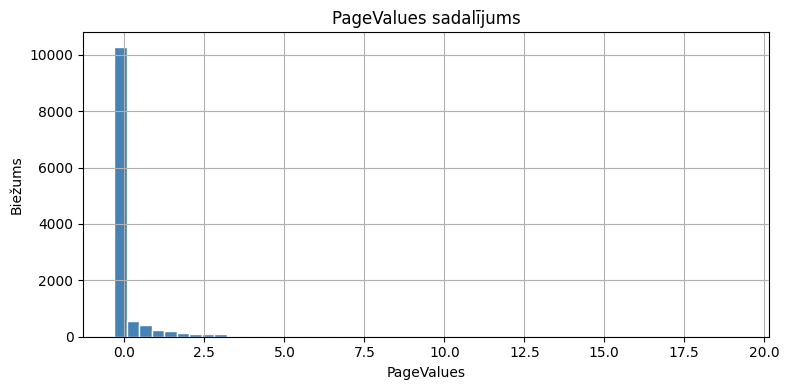

In [20]:
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


# Kāpēc Revenue tika izņemta no features?

Revenue kolonna tika izņemta no features, lai novērstu data leakage. 
Data leakage rodas tad, ja modelis izmanto informāciju, kas prognozēšanas brīdī reālajā dzīvē nebūtu pieejama.

Šajā gadījumā Revenue ir cieši saistīta ar gala rezultātu (vai notika pirkums), 
tāpēc modelis varētu “krāpties” un iegūt nereāli labus rezultātus.

Tāpēc Revenue netiek izmantota modelī.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Izveido modeli
lr_model = LinearRegression()

# Trenē modeli
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineārā regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineārā regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


# Lineārās regresijas metriku interpretācija

MAE (Mean Absolute Error) parāda vidējo absolūto kļūdu starp prognozēto un faktisko PageValues vērtību. 
Šajā modelī MAE ir aptuveni 0.5009, kas nozīmē, ka prognozes vidēji atšķiras no reālajām vērtībām par apmēram 0.5 vienībām.

RMSE (Root Mean Squared Error) arī mēra prognozes kļūdu, bet lielākas kļūdas tiek sodītas vairāk, jo tās tiek kvadrētas. 
Šajā gadījumā RMSE ir 0.9946, kas ir lielāks par MAE, un tas norāda, ka dažos gadījumos modelim ir lielākas novirzes.

R² (R-squared) parāda, cik lielu daļu no PageValues variācijas modelis spēj izskaidrot. 
Šeit R² ir 0.0456, kas nozīmē, ka modelis izskaidro tikai apmēram 4.56% no datu variācijas.

Kopumā lineārās regresijas modelis nav ļoti spēcīgs, jo R² vērtība ir zema. 
Tas nozīmē, ka lineārais modelis nespēj labi uztvert sakarības šajos datos un prognožu kvalitāte ir ierobežota.

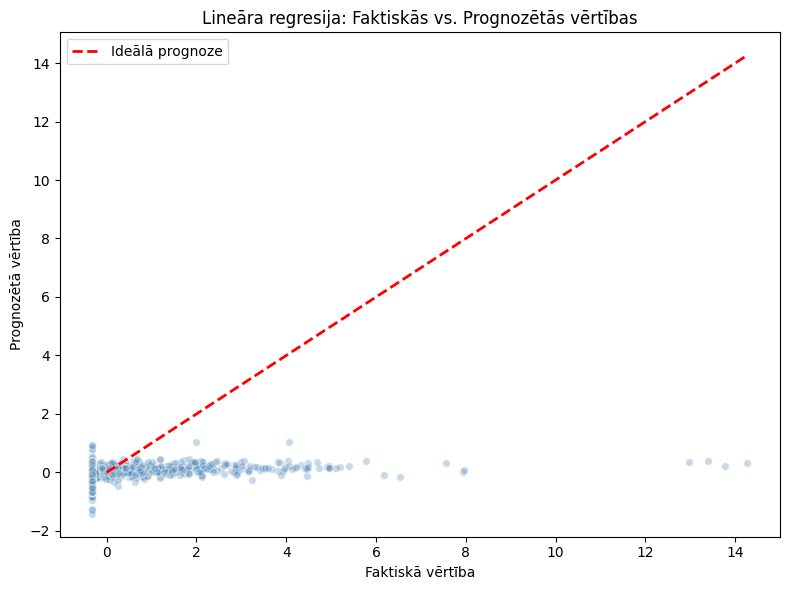

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

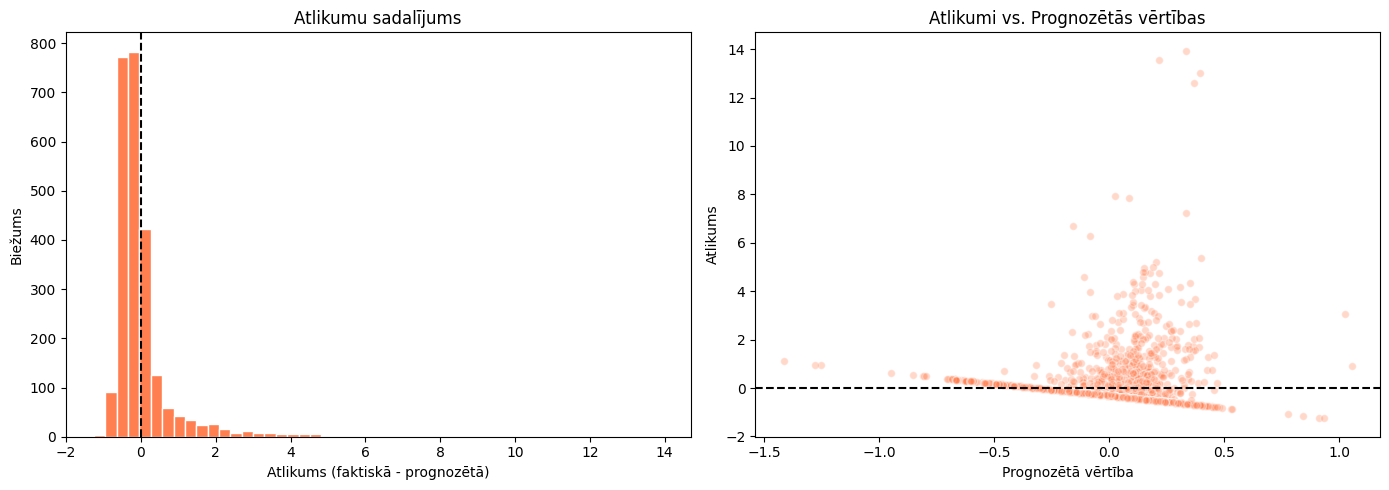

In [24]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

# Vizualizāciju interpretācija

Scatter grafikā (faktiskās vs prognozētās vērtības) punkti nav tuvu ideālajai līnijai, kas norāda, ka modelis nespēj precīzi prognozēt PageValues. Īpaši pie lielākām vērtībām modelis prognozē ievērojami zemākas vērtības.

Atlikumu histogramma nav simetriska ap 0, kas nozīmē, ka modelim ir bias un kļūdas nav vienmērīgi sadalītas.

Atlikumu grafiks pret prognozētajām vērtībām neizskatās kā nejaušs punktu mākonis. Redzama struktūra un tendence, kas norāda, ka modelis sistemātiski kļūdās.

Kopumā šīs vizualizācijas parāda, ka lineārais modelis nespēj labi uztvert datu sakarības un prognožu kvalitāte ir zema.

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

y_pred_poly = poly_pipeline.predict(X_test)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364


In [26]:
r2_train_lr = lr_model.score(X_train, y_train)
r2_test_lr = lr_model.score(X_test, y_test)

r2_train_poly = poly_pipeline.score(X_train, y_train)
r2_test_poly = poly_pipeline.score(X_test, y_test)

print("=== R² uz treniņa un testa datiem ===")
print(f"Lineārā regresija - train R²: {r2_train_lr:.4f}")
print(f"Lineārā regresija - test R²:  {r2_test_lr:.4f}")
print(f"Polinomiālā regresija - train R²: {r2_train_poly:.4f}")
print(f"Polinomiālā regresija - test R²:  {r2_test_poly:.4f}")

if abs(r2_train_lr - r2_test_lr) > 0.10:
    print("Brīdinājums: lineārajam modelim iespējams overfitting.")

if abs(r2_train_poly - r2_test_poly) > 0.10:
    print("Brīdinājums: polinomiālajam modelim iespējams overfitting.")

=== R² uz treniņa un testa datiem ===
Lineārā regresija - train R²: 0.0568
Lineārā regresija - test R²:  0.0456
Polinomiālā regresija - train R²: 0.1334
Polinomiālā regresija - test R²:  0.0364


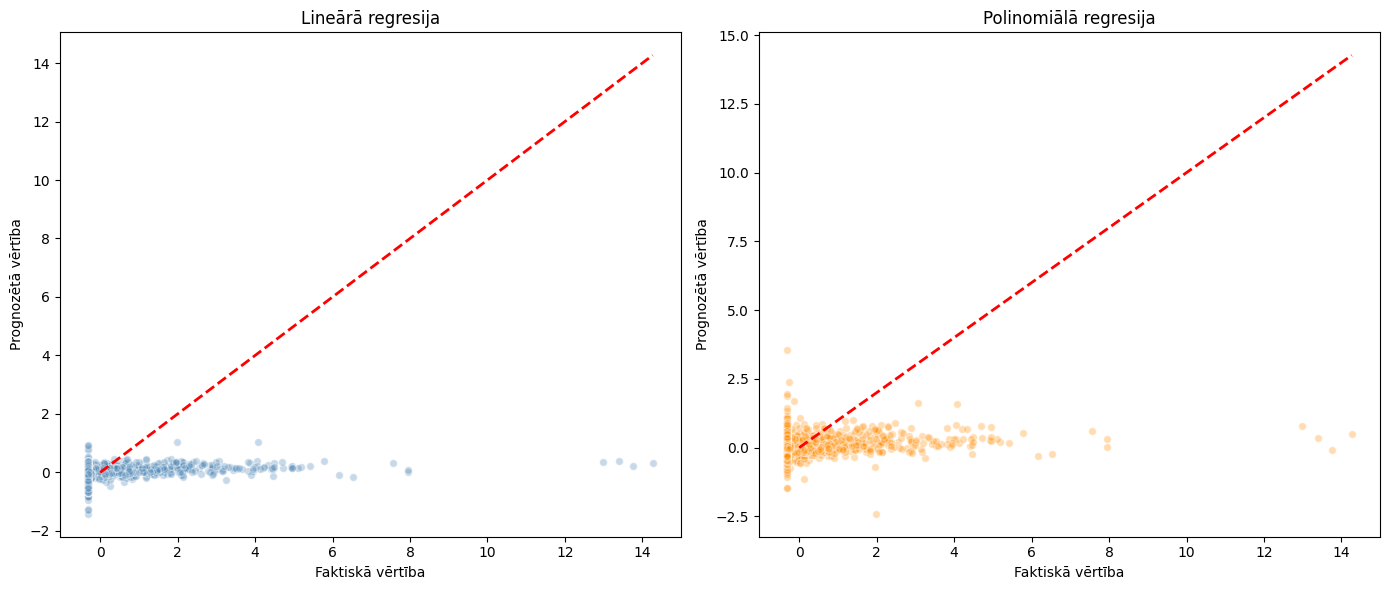

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lineārā regresija
max_val_lr = max(y_test.max(), y_pred.max())
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)
axes[0].plot([0, max_val_lr], [0, max_val_lr], 'r--', linewidth=2)
axes[0].set_title('Lineārā regresija')
axes[0].set_xlabel('Faktiskā vērtība')
axes[0].set_ylabel('Prognozētā vērtība')

# Polinomiālā regresija
max_val_poly = max(y_test.max(), y_pred_poly.max())
axes[1].scatter(y_test, y_pred_poly, alpha=0.3, color='darkorange', edgecolors='white', s=30)
axes[1].plot([0, max_val_poly], [0, max_val_poly], 'r--', linewidth=2)
axes[1].set_title('Polinomiālā regresija')
axes[1].set_xlabel('Faktiskā vērtība')
axes[1].set_ylabel('Prognozētā vērtība')

plt.tight_layout()
plt.show()

# Secinājumi par modeļiem

Salīdzinot lineāro un polinomiālo regresiju, redzams, ka lineārais modelis darbojas nedaudz labāk. Lineārās regresijas R² ir aptuveni 0.0456, savukārt polinomiālajai regresijai tas ir vēl zemāks — ap 0.0364. Tas nozīmē, ka polinomiālais modelis neuzlabo prognozes kvalitāti.

MAE vērtības abiem modeļiem ir līdzīgas, bet RMSE polinomiālajam modelim ir nedaudz lielāks, kas norāda uz lielākām kļūdām atsevišķos gadījumos.

Analizējot train un test R² vērtības, redzams, ka polinomiālajam modelim ir izteiktas overfitting pazīmes — tas daudz labāk darbojas uz treniņa datiem nekā uz testa datiem. Tas nozīmē, ka modelis pārāk pielāgojas treniņa datiem un slikti generalizē jaunus datus.

Grafikos redzams, ka abi modeļi nespēj labi prognozēt lielākas PageValues vērtības un bieži prognozē vērtības tuvu nullei.

Kopumā lineārais modelis ir stabilāks un vienkāršāks, tāpēc biznesa vidē būtu ieteicams izmantot lineāro regresiju, nevis polinomiālo, kas šajā gadījumā tikai palielina sarežģītību bez būtiska ieguvuma.

## C daļa – Modeļu salīdzinājums un biznesa secinājumi

### Modeļu veiktspējas salīdzinājums

Šajā analīzē tika salīdzināti trīs modeļi:

- Decision Tree
- Random Forest
- Logistic Regression

Galvenā metrika: **F1 score**, jo dati ir nelīdzsvaroti (~15% pirkumu).

| Modelis              | F1 score |
|----------------------|---------|
| Random Forest        | ~0.61   |
| Decision Tree        | ~0.57   |
| Logistic Regression  | ~0.48   |

---

### Kurš modelis ir labākais?

**Random Forest modelis uzrāda labāko rezultātu.**

Tas:
- visprecīzāk identificē pircējus  
- rada mazāk kļūdu  
- nodrošina labāku balansu starp precision un recall  

---

### Kāpēc tas ir svarīgi biznesā?

Uzņēmuma mērķis:
 identificēt lietotājus, kas varētu veikt pirkumu

Svarīgākais risks:
 **nepamanīt potenciālu klientu (False Negative)**

No rezultātiem redzams:
- Logistic Regression biežāk palaid garām pirkumus  
- Decision Tree ir vidējs  
- **Random Forest vislabāk samazina šo risku**

---

### Biznesa ietekme

Izmantojot Random Forest modeli:

✔ Var precīzāk atlasīt potenciālos klientus  
✔ Var optimizēt mārketinga budžetu  
✔ Var palielināt konversijas rādītājus  
✔ Samazinās zaudētie klienti  

---

### Vai modelis ir pietiekami labs?

F1 score ~0.61 nozīmē:
- modelis strādā labāk par nejaušību  
- bet vēl ir vieta uzlabojumiem  

---

### Ieteikumi uzlabojumiem

Lai uzlabotu rezultātus, ieteicams:

- Feature engineering (jaunu pazīmju veidošana)
- Hyperparameter tuning
- Klases balansēšana (piem., SMOTE)
- Citu modeļu izmantošana (XGBoost, LightGBM)

---

### Gala secinājums

**Random Forest modelis ir vispiemērotākais šim uzdevumam.**

Tas:
- nodrošina labāko prognozēšanas kvalitāti  
- vislabāk identificē pircējus  
- sniedz lielāko biznesa vērtību  

Ieteicams izmantot šo modeli kā pamatu turpmākai optimizācijai un ieviešanai.